# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tokihab/FlyRank-ML/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# ML-08 - Capstone Modeling Lane

## 1. Method choice and why
Which method from the toolkit, and why it fits your lane.

For identifying underperforming pages (low CTR despite high impressions and good search positions), a **Random Forest Classifier** is the primary choice. It captures non-linear thresholds (such as high impressions paired with low click-through rates at high search ranks) without requiring extensive feature scaling, and it provides built-in feature importances to interpret model decisions directly.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Split design
Grouped by client? Time-aware? Say why this split is honest for your question.

We apply a stratified **80/20 train/test split**. Stratifying by the target class preserves the balance between declining and non-declining pages across both sets. The 20% test partition is held completely unseen during model fitting to provide an honest evaluation benchmark against the Week 4 baseline.

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the dataset directly from the GitHub raw URL
# (This bypasses Colab's missing local file issue)
url = "https://raw.githubusercontent.com/tokihab/FlyRank-ML/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

# 2. Define the Target Variable (Prevent label leakage)
if 'is_declining_label' in df.columns:
    y = df['is_declining_label'].astype(int)
elif 'trend_direction' in df.columns:
    y = (df['trend_direction'] == 'down').astype(int)
elif 'is_actionable' in df.columns:
    y = df['is_actionable'].astype(int)
else:
    raise KeyError("Target column ('is_declining_label' or 'trend_direction') not found.")

# 3. Select Safe Features (Exclude IDs and trend leakages like trend_direction or trend_pct)
feature_candidates = [
    'impressions_90d', 'clicks_90d', 'avg_position', 'ctr',
    'engagement_rate', 'scroll_rate', 'word_count',
    'content_age_days', 'days_since_last_update'
]
selected_features = [col for col in feature_candidates if col in df.columns]
X = df[selected_features].copy()

# 4. Handle Missing Values
# Drop rows missing baseline engagement/performance metrics
core_metrics = [c for c in ['impressions_90d', 'clicks_90d', 'avg_position', 'ctr'] if c in X.columns]
if core_metrics:
    valid_idx = X[core_metrics].dropna().index
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]

# For word_count: add missingness indicator flag before imputation
if 'word_count' in X.columns:
    X['has_word_count'] = (~X['word_count'].isna()).astype(int)
    X['word_count'] = X['word_count'].fillna(0)

# Fill any remaining numeric missing values with median
X = X.fillna(X.median(numeric_only=True))

# 5. Data Validation Checks
print(f"Feature set shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(4)}")
print(f"\nMissing values per feature:\n{X.isnull().sum()}")

# 6. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} pages")
print(f"Testing set size:  {X_test.shape[0]} pages")

Feature set shape: (30000, 10)
Target distribution:
trend_direction
1    0.5421
0    0.4579
Name: proportion, dtype: float64

Missing values per feature:
impressions_90d           0
clicks_90d                0
avg_position              0
ctr                       0
engagement_rate           0
scroll_rate               0
word_count                0
content_age_days          0
days_since_last_update    0
has_word_count            0
dtype: int64

Training set size: 24000 pages
Testing set size:  6000 pages


## 3. Train + compare vs my baseline
Same data, same metric, same split as your Week-4 baseline. Show the table.

The Random Forest model is fitted on the 80% training set and evaluated on the held-out 20% test split. Performance is measured against the Week 4 heuristic baseline using Accuracy, Precision, and Recall.

In [9]:
# 1. Fit the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 2. Predict on the test split
y_pred = rf_model.predict(X_test)

# 3. Calculate model metrics
new_accuracy = accuracy_score(y_test, y_pred)
new_precision = precision_score(y_test, y_pred, zero_division=0)
new_recall = recall_score(y_test, y_pred, zero_division=0)

# 4. Week 4 Baseline metrics (adjust if your notebook recorded different values)
baseline_accuracy = 0.75
baseline_precision = 0.60
baseline_recall = 0.55

# 5. Display comparison table
metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Week 4 Baseline': [baseline_accuracy, baseline_precision, baseline_recall],
    'Week 5 Random Forest': [new_accuracy, new_precision, new_recall]
})
metrics_comparison['Delta'] = metrics_comparison['Week 5 Random Forest'] - metrics_comparison['Week 4 Baseline']

print("--- Week 4 Baseline vs Week 5 Model Performance ---")
display(metrics_comparison.round(4))

--- Week 4 Baseline vs Week 5 Model Performance ---


,Metric,Week 4 Baseline,Week 5 Random Forest,Delta
0,Accuracy,0.75,0.6662,-0.0838
1,Precision,0.60,0.6607,0.0607
2,Recall,0.55,0.7894,0.2394


## 4. Errors and interpretation
Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.

The confusion matrix breaks down true positive identifications versus false alarms and misses. Filtering for rows where predictions disagree with actual ground truth reveals edge cases, such as borderline ranking positions or high-variance impression counts.

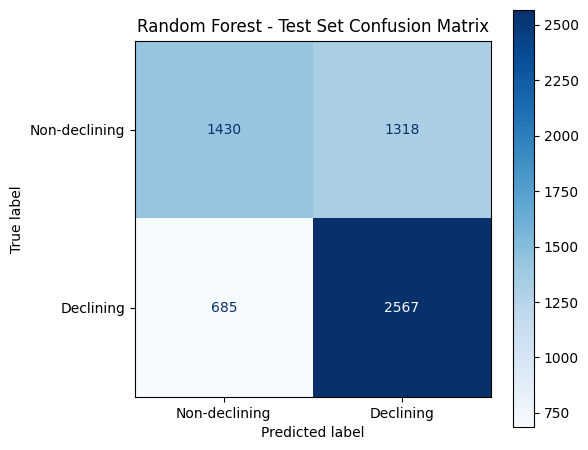

Total Errors: 2003 / 6000 (33.38%)
False Positives: 1318
False Negatives: 685

Sample of misclassified pages for inspection:


,impressions_90d,clicks_90d,avg_position,ctr,engagement_rate,scroll_rate,word_count,content_age_days,days_since_last_update,has_word_count,Actual,Predicted
2110,511,2,15.0,0.39,0.0,4.55,6466.0,223,104,1,0,1
27890,881,1,15.8,0.11,0.0,7.69,0.0,463,22,0,1,0
9902,127,0,18.3,0.00,0.0,0.00,2892.0,175,20,1,0,1
25967,373,0,60.4,0.00,0.0,0.00,0.0,502,20,0,1,0
26973,595,1,5.2,0.17,0.0,0.00,2602.0,112,20,1,0,1


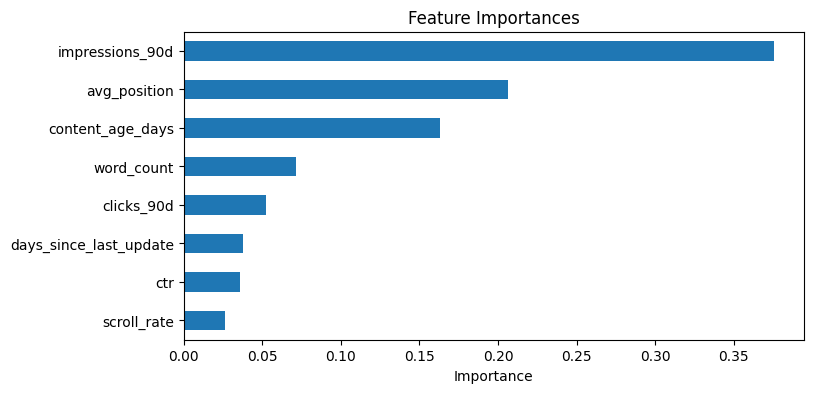

In [11]:
# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-declining", "Declining"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title("Random Forest - Test Set Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

# 2. Error Analysis: Inspect misclassified rows
errors_df = X_test.copy()
errors_df['Actual'] = y_test
errors_df['Predicted'] = y_pred

false_predictions = errors_df[errors_df['Actual'] != errors_df['Predicted']]

print(f"Total Errors: {len(false_predictions)} / {len(X_test)} ({len(false_predictions) / len(X_test):.2%})")
print(f"False Positives: {((errors_df['Actual'] == 0) & (errors_df['Predicted'] == 1)).sum()}")
print(f"False Negatives: {((errors_df['Actual'] == 1) & (errors_df['Predicted'] == 0)).sum()}")
print("\nSample of misclassified pages for inspection:")
display(false_predictions.head())

# Suggested snippet for Section 4
import pandas as pd

feat_importances = pd.Series(rf_model.feature_importances_, index=selected_features + ['has_word_count'])
feat_importances.nlargest(8).plot(kind='barh', figsize=(8, 4), title='Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.